# Exploratory Data Analysis (EDA)
### Dataset: Breast Cancer METABRIC (cleaned)

In [5]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

pd.set_option("display.max_columns", None)
warnings.filterwarnings("ignore")

In [6]:
# Paths
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
CLEAN_DATA_PATH = DATA_DIR / "cleaned_data.csv"

data = pd.read_csv(CLEAN_DATA_PATH, index_col="Patient ID")
df = data.copy()
df.head()

,Age at Diagnosis,Type of Breast Surgery,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,ER Status,Neoplasm Histologic Grade,HER2 Status,Tumor Other Histologic Subtype,Hormone Therapy,Inferred Menopausal State,Integrative Cluster,Primary Tumor Laterality,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Oncotree Code,Overall_Survival_Status,PR Status,Radio Therapy,3-Gene classifier subtype,Tumor Size,Tumor Stage
Patient ID,,,,,,,,,,,,,,,,,,,,,,,,
MB-0000,75.65,Mastectomy,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,Positive,3.0,Negative,Ductal/NST,Yes,Post,4ER+,Right,10.0,NaN,6.044,IDC,Living,Negative,Yes,ER-/HER2-,22.0,2.0
MB-0002,43.19,Breast Conserving,Breast Invasive Ductal Carcinoma,High,No,LumA,Positive,3.0,Negative,Ductal/NST,Yes,Pre,4ER+,Right,0.0,2.0,4.020,IDC,Living,Positive,Yes,ER+/HER2- High Prolif,10.0,1.0
MB-0005,48.87,Mastectomy,Breast Invasive Ductal Carcinoma,High,Yes,LumB,Positive,2.0,Negative,Ductal/NST,Yes,Pre,3,Right,1.0,2.0,4.030,IDC,Deceased,Positive,No,NaN,15.0,2.0
MB-0006,47.68,Mastectomy,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,Positive,2.0,Negative,Mixed,Yes,Pre,9,Right,3.0,1.0,4.050,MDLC,Living,Positive,Yes,NaN,25.0,2.0
MB-0008,76.97,Mastectomy,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,Positive,3.0,Negative,Mixed,Yes,Post,9,Right,8.0,2.0,6.080,MDLC,Deceased,Positive,Yes,ER+/HER2- High Prolif,40.0,2.0


## 1. Dataset overview

In [7]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (1978, 24)
<class 'pandas.core.frame.DataFrame'>
Index: 1978 entries, MB-0000 to MB-7299
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age at Diagnosis                1978 non-null   float64
 1   Type of Breast Surgery          1953 non-null   object 
 2   Cancer Type Detailed            1978 non-null   object 
 3   Cellularity                     1915 non-null   object 
 4   Chemotherapy                    1977 non-null   object 
 5   Pam50 + Claudin-low subtype     1977 non-null   object 
 6   ER Status                       1978 non-null   object 
 7   Neoplasm Histologic Grade       1893 non-null   float64
 8   HER2 Status                     1977 non-null   object 
 9   Tumor Other Histologic Subtype  1936 non-null   object 
 10  Hormone Therapy                 1977 non-null   object 
 11  Inferred Menopausal State       1977 non-null   object 
 12  Inte

In [8]:
TARGET = "Overall_Survival_Status"

numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = [c for c in df.select_dtypes(include="object").columns if c != TARGET]

print("Numeric columns (%d):\n" % len(numeric_cols), numeric_cols)
print("\nCategorical columns (%d):\n" % len(categorical_cols), categorical_cols)

Numeric columns (7):
 ['Age at Diagnosis', 'Neoplasm Histologic Grade', 'Lymph nodes examined positive', 'Mutation Count', 'Nottingham prognostic index', 'Tumor Size', 'Tumor Stage']

Categorical columns (16):
 ['Type of Breast Surgery', 'Cancer Type Detailed', 'Cellularity', 'Chemotherapy', 'Pam50 + Claudin-low subtype', 'ER Status', 'HER2 Status', 'Tumor Other Histologic Subtype', 'Hormone Therapy', 'Inferred Menopausal State', 'Integrative Cluster', 'Primary Tumor Laterality', 'Oncotree Code', 'PR Status', 'Radio Therapy', '3-Gene classifier subtype']


In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age at Diagnosis,1978.0,NaN,NaN,NaN,61.097144,12.956272,21.93,51.4275,61.86,70.6075,96.29
Type of Breast Surgery,1953,2,Mastectomy,1169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cancer Type Detailed,1978,7,Breast Invasive Ductal Carcinoma,1537,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cellularity,1915,3,High,964,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Chemotherapy,1977,2,No,1565,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pam50 + Claudin-low subtype,1977,7,LumA,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ER Status,1978,2,Positive,1506,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Neoplasm Histologic Grade,1893.0,NaN,NaN,NaN,2.414157,0.649158,1.0,2.0,3.0,3.0,3.0
HER2 Status,1977,2,Negative,1730,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tumor Other Histologic Subtype,1936,8,Ductal/NST,1491,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Missing values

In [10]:
null_summary = pd.DataFrame({
    "nulls": df.isnull().sum(),
    "pct_missing": (df.isnull().mean() * 100).round(2)
}).sort_values("pct_missing", ascending=False)

null_summary[null_summary["nulls"] > 0]

,nulls,pct_missing
Tumor Stage,514,25.99
3-Gene classifier subtype,216,10.92
Mutation Count,119,6.02
Primary Tumor Laterality,110,5.56
Neoplasm Histologic Grade,85,4.30
Lymph nodes examined positive,74,3.74
Cellularity,63,3.19
Tumor Other Histologic Subtype,42,2.12
Type of Breast Surgery,25,1.26
Tumor Size,23,1.16


In [11]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

cat_imputer = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

print("Remaining nulls:", df.isnull().sum().sum())

Remaining nulls: 0


## 4. Target distribution

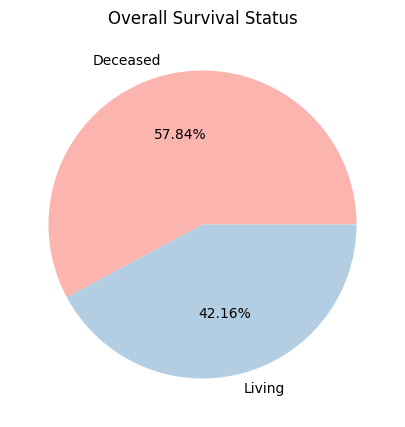

Overall_Survival_Status
Deceased    1144
Living       834
Name: count, dtype: int64


In [12]:
survival_status = df[TARGET].value_counts()

plt.figure(figsize=(6, 5))
plt.pie(
    survival_status,
    labels=survival_status.index,
    autopct="%.2f%%",
    colors=plt.cm.Pastel1.colors
)
plt.title("Overall Survival Status")
plt.show()

print(survival_status)

The classes are imbalanced (roughly 58/42) — worth keeping in mind for model selection later: accuracy alone won't be a great metric, and stratified train/test splitting plus class-weighting or resampling should be considered in the training script.

## 5. Categorical feature distributions

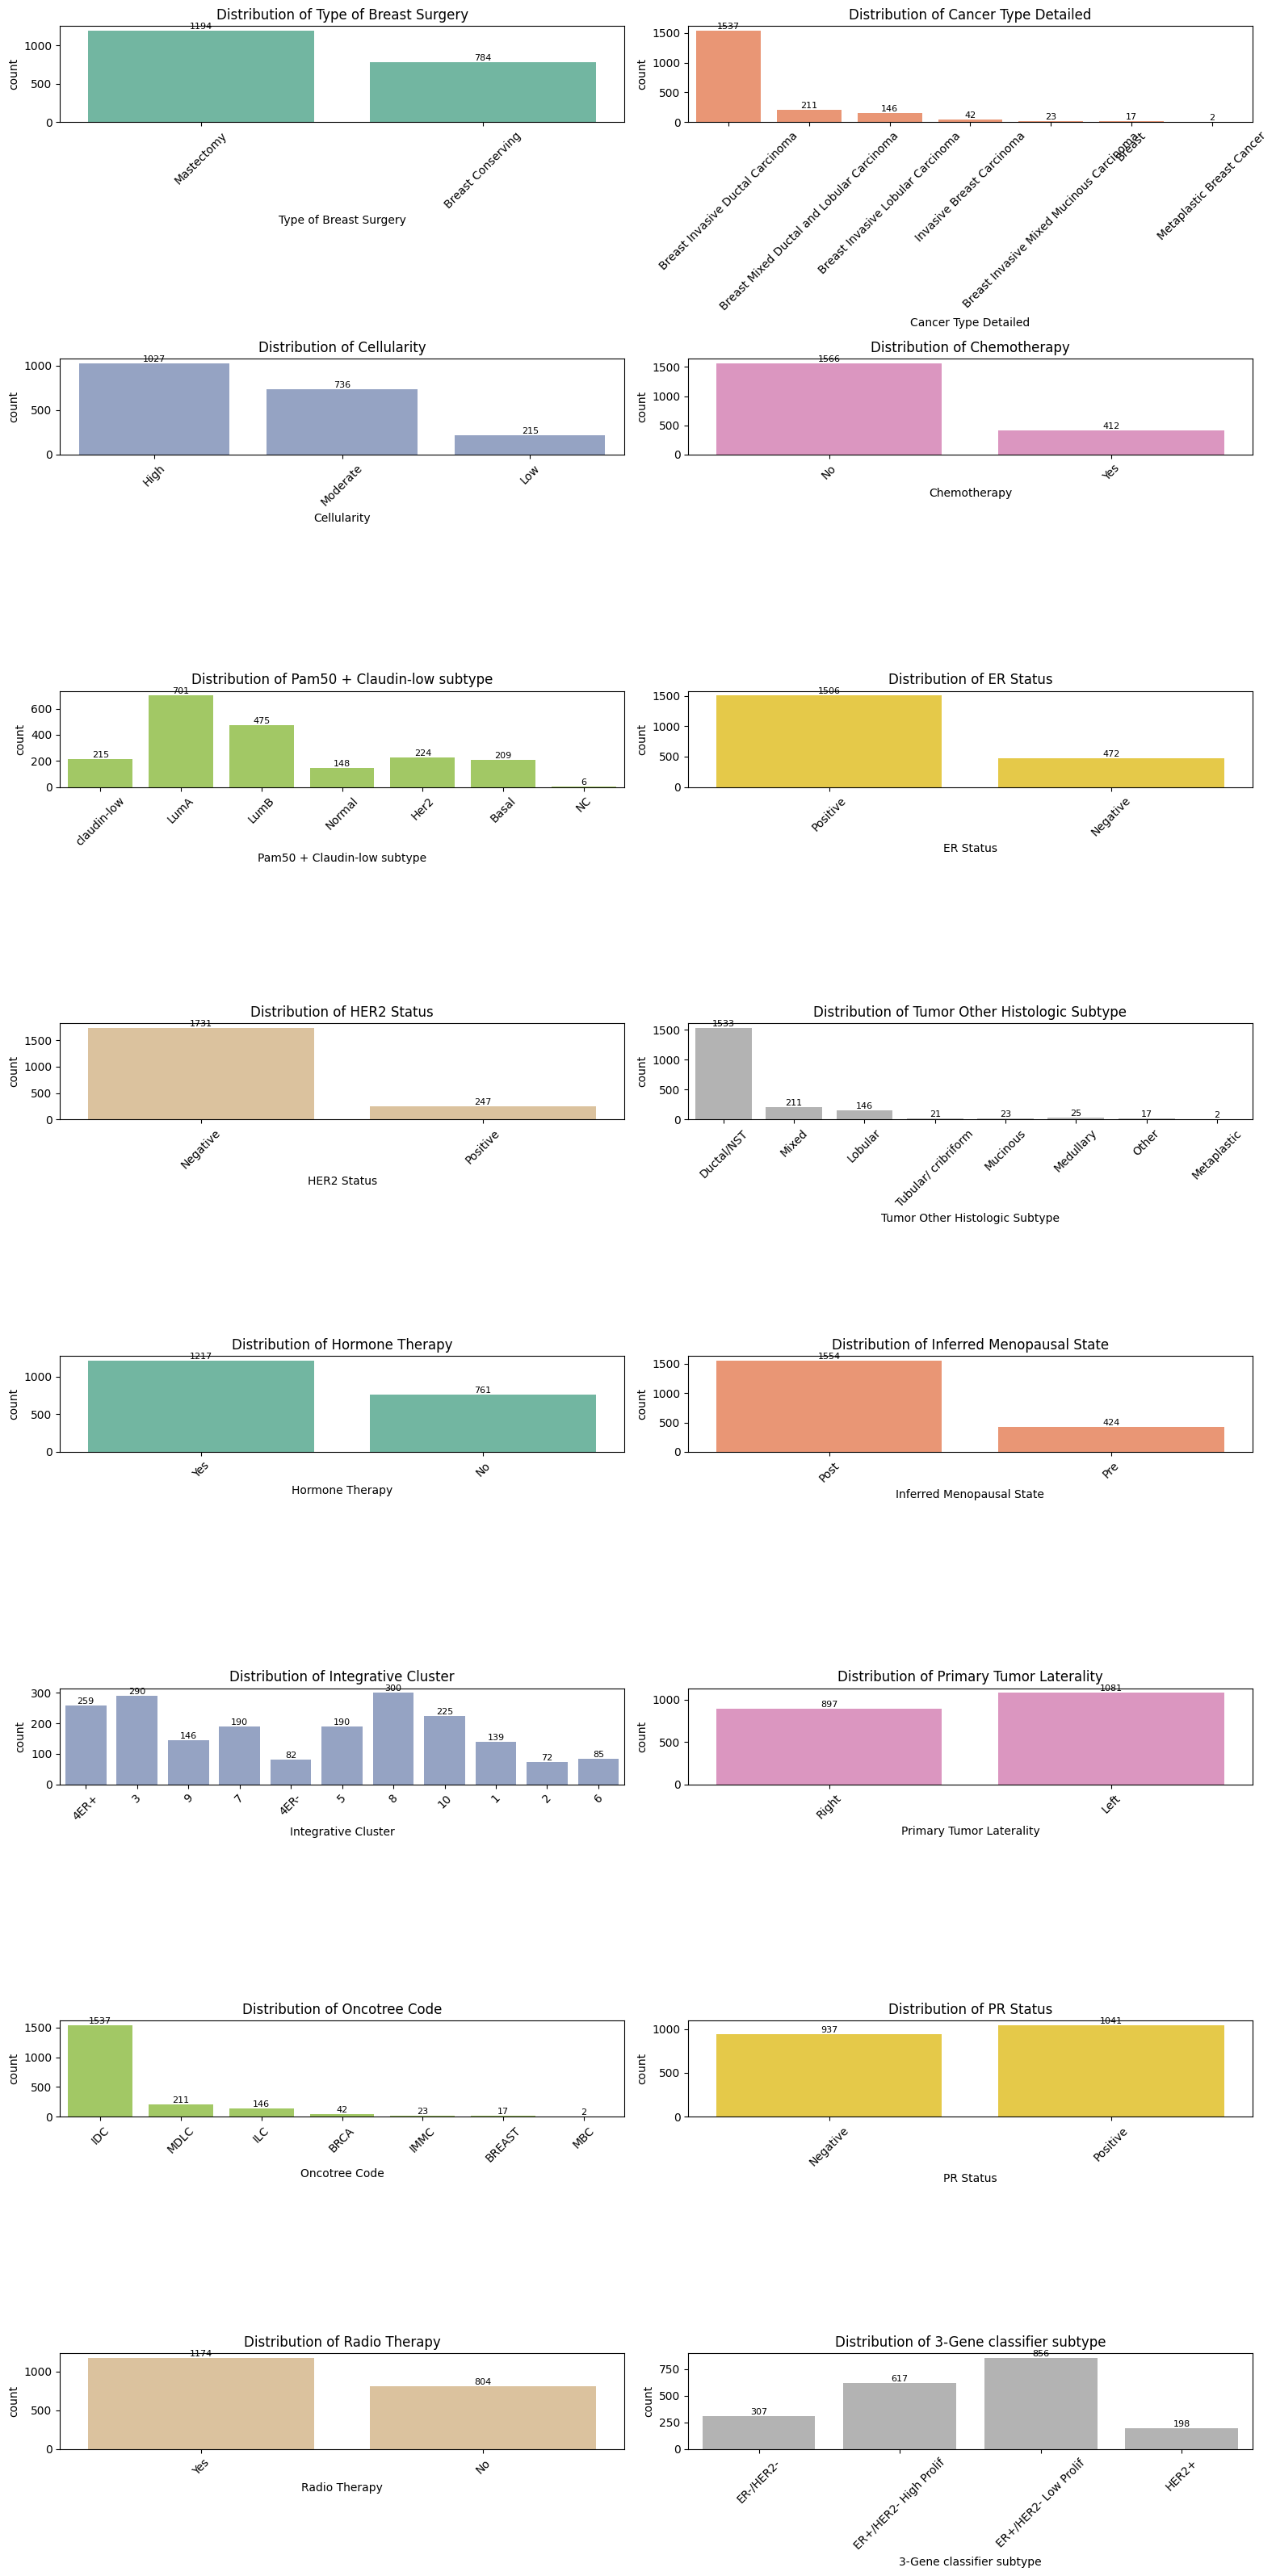

In [13]:
n_cols = 2
n_rows = -(-len(categorical_cols) // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

palette = sns.color_palette("Set2", len(categorical_cols))

for ax, col, color in zip(axes, categorical_cols, palette):
    sns.countplot(data=df, x=col, color=color, ax=ax)
    ax.set_title(f"Distribution of {col}", fontsize=12)
    ax.tick_params(axis="x", rotation=45)
    for container in ax.containers:
        ax.bar_label(container, label_type="edge", fontsize=8)

for ax in axes[len(categorical_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 6. Numeric feature distributions

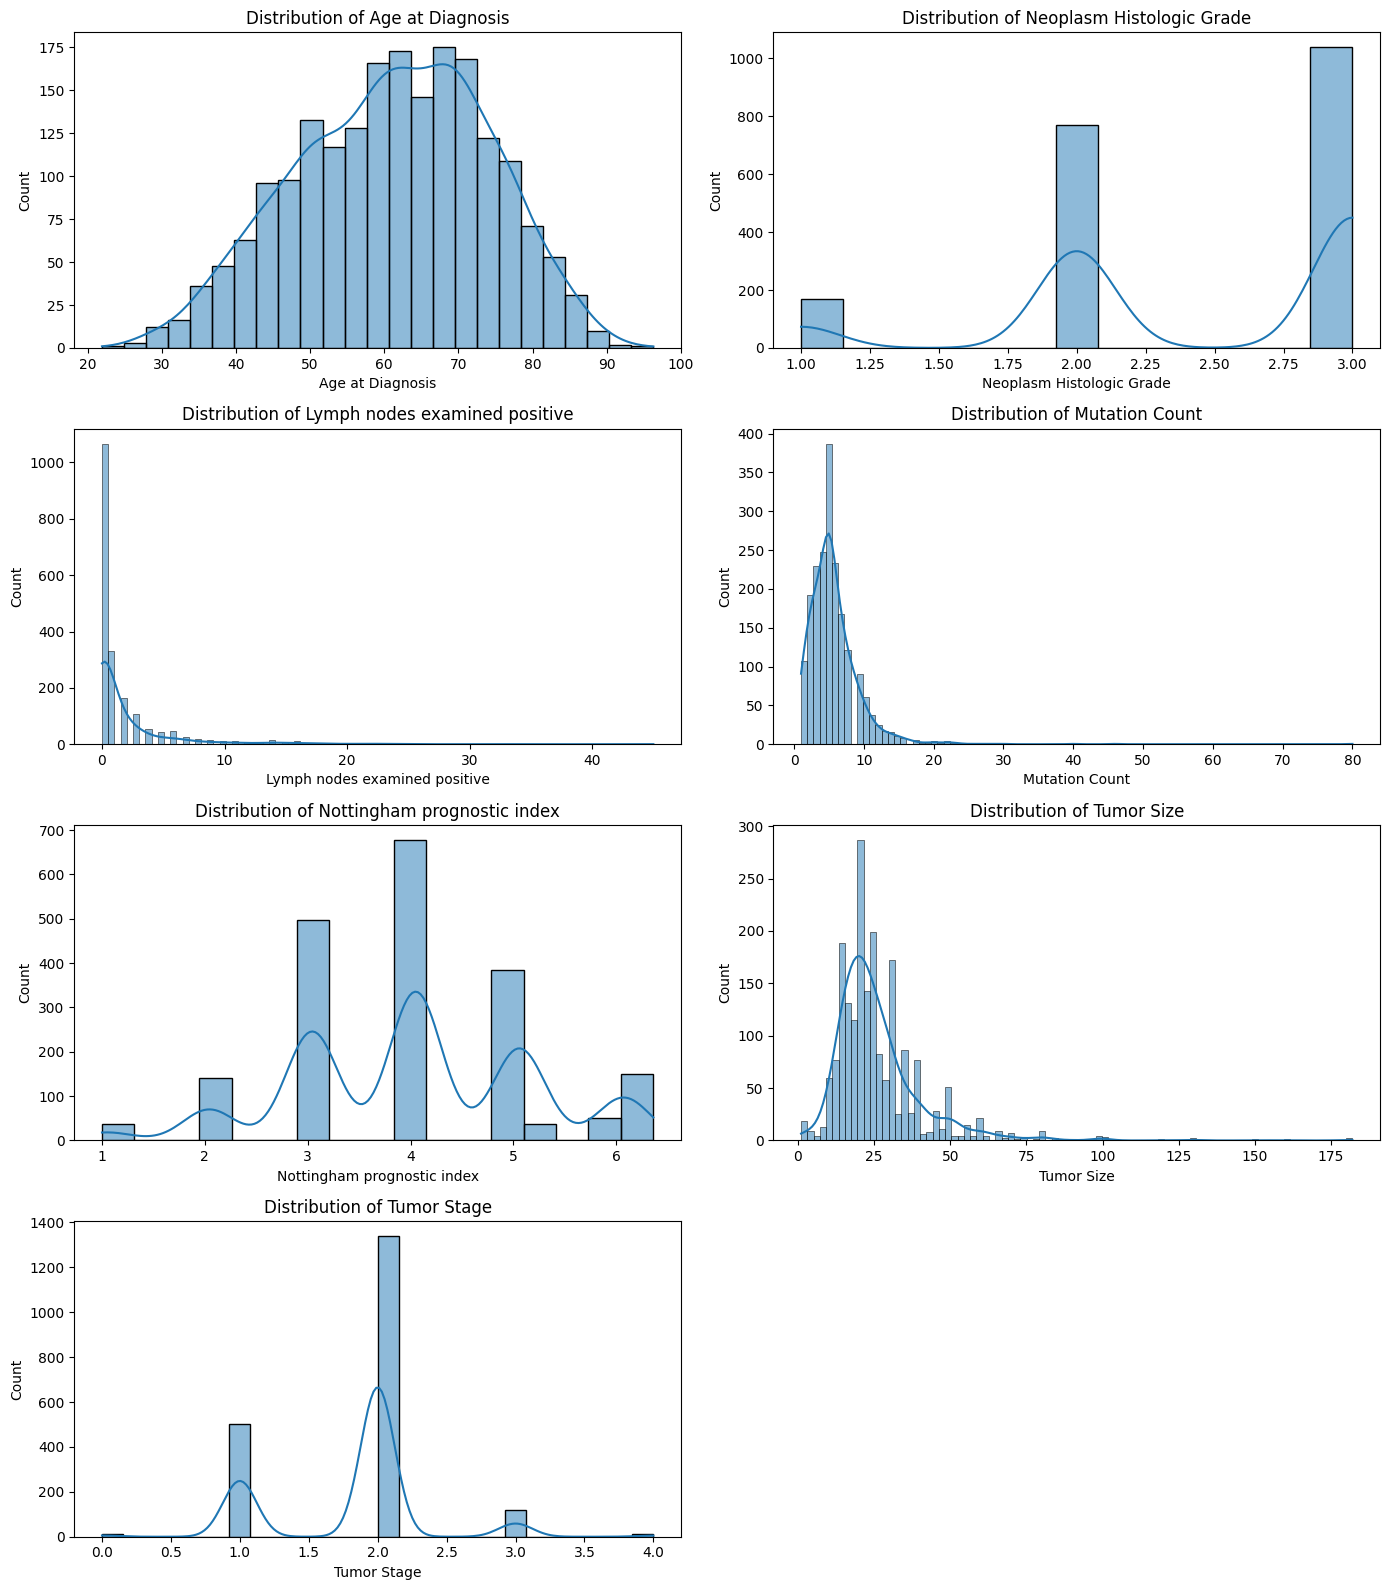

In [14]:
n_cols = 2
n_rows = -(-len(numeric_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

for ax in axes[len(numeric_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Outlier check
Boxplots to spot extreme values. Note: extreme tumor sizes or mutation counts can be real clinical findings rather than data errors, so nothing is removed automatically here — this is a visual check to decide, feature by feature, whether capping/winsorizing is warranted in the modeling pipeline.

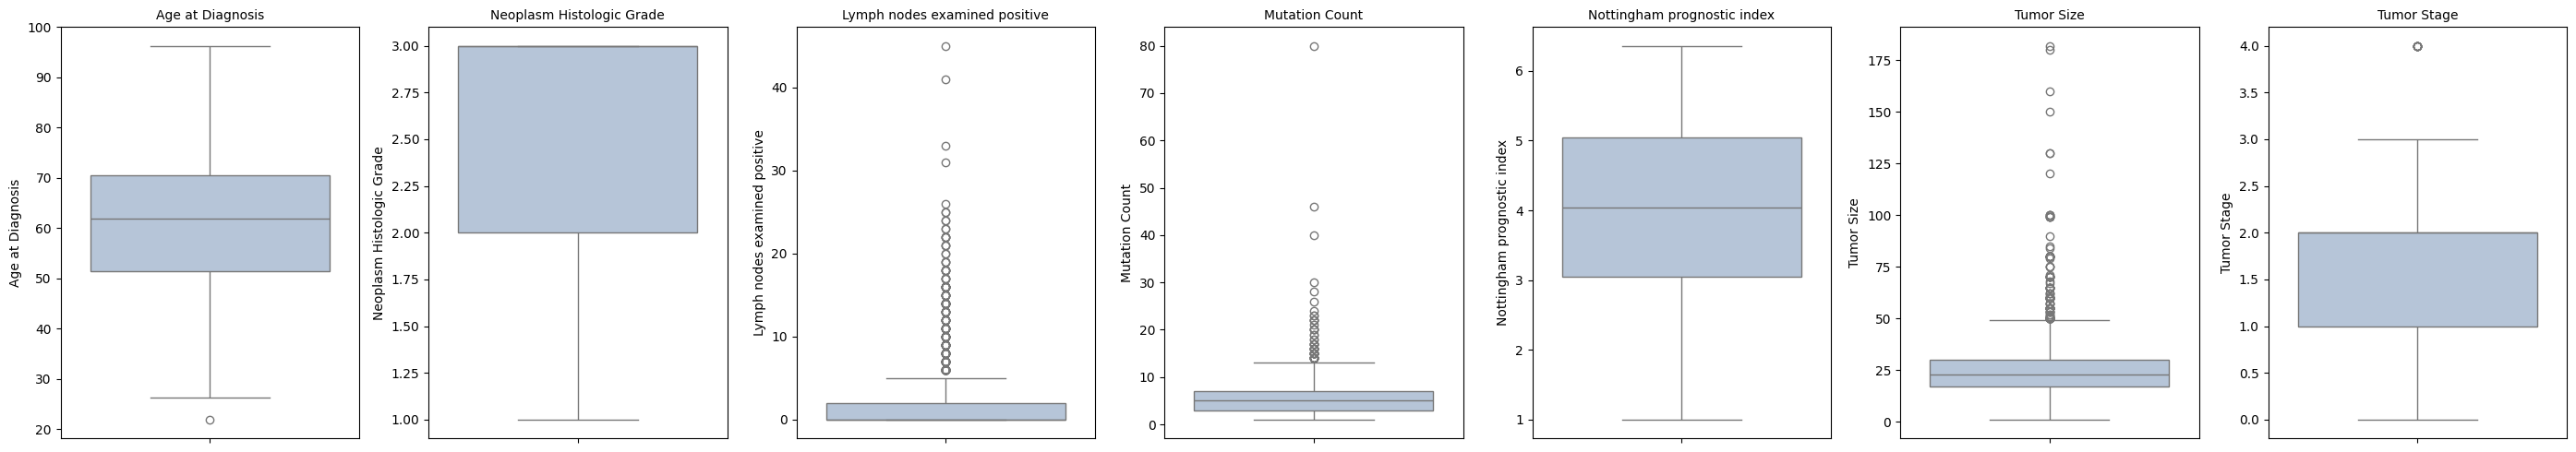

In [15]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(4 * len(numeric_cols), 5))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="lightsteelblue")
    ax.set_title(col, fontsize=10)

plt.tight_layout()
plt.show()

## 7. Survival chances by categorical values

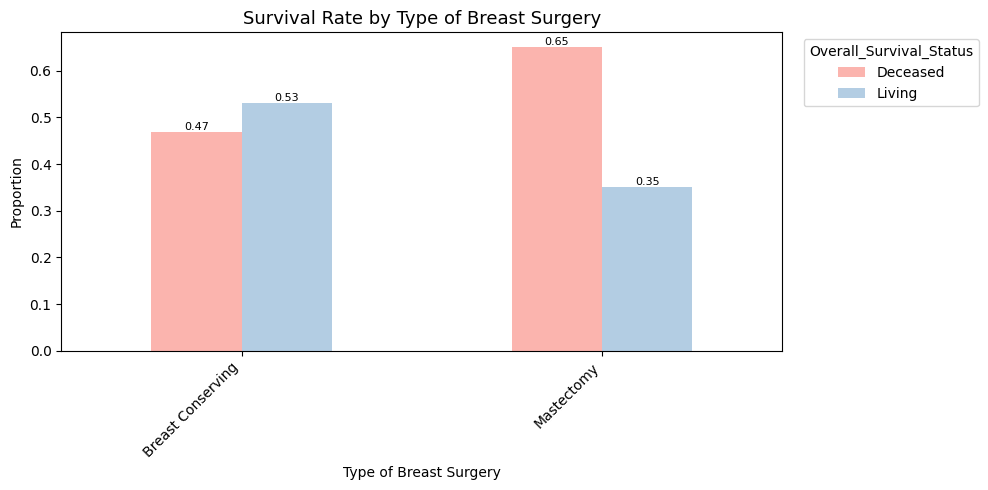

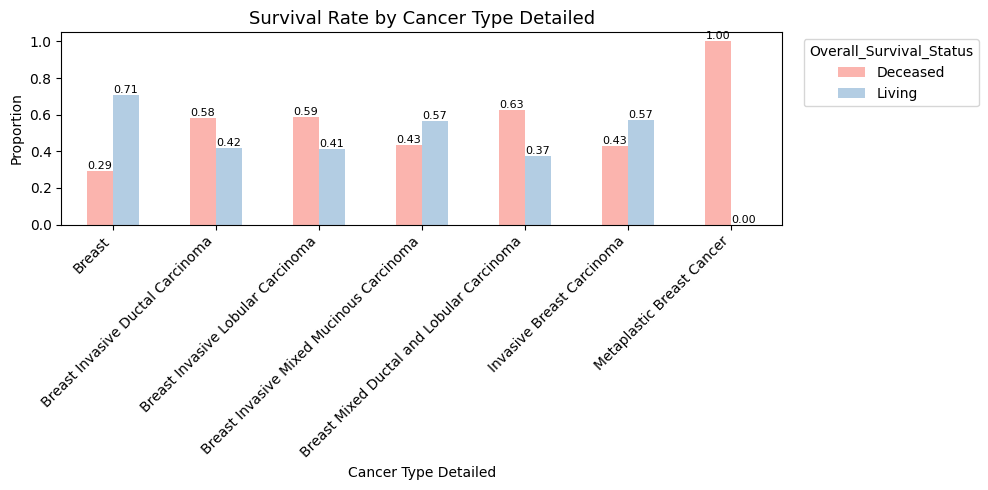

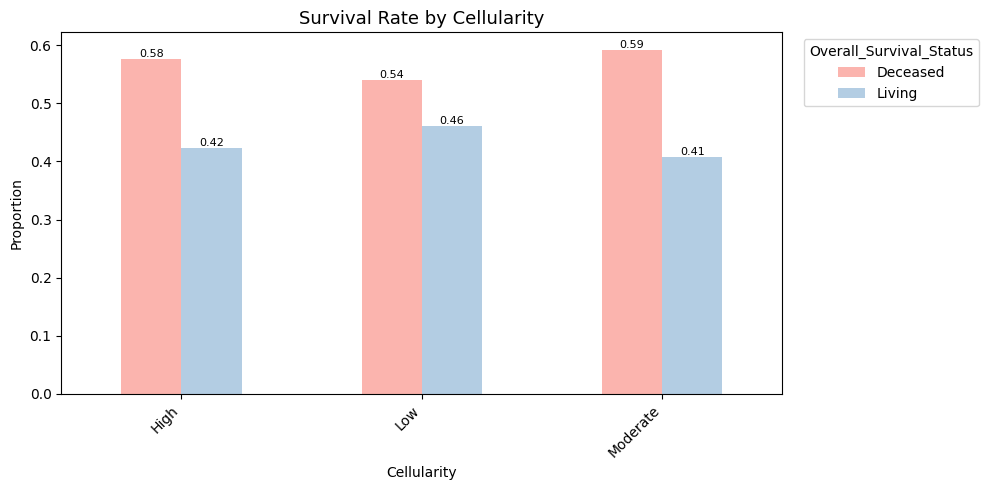

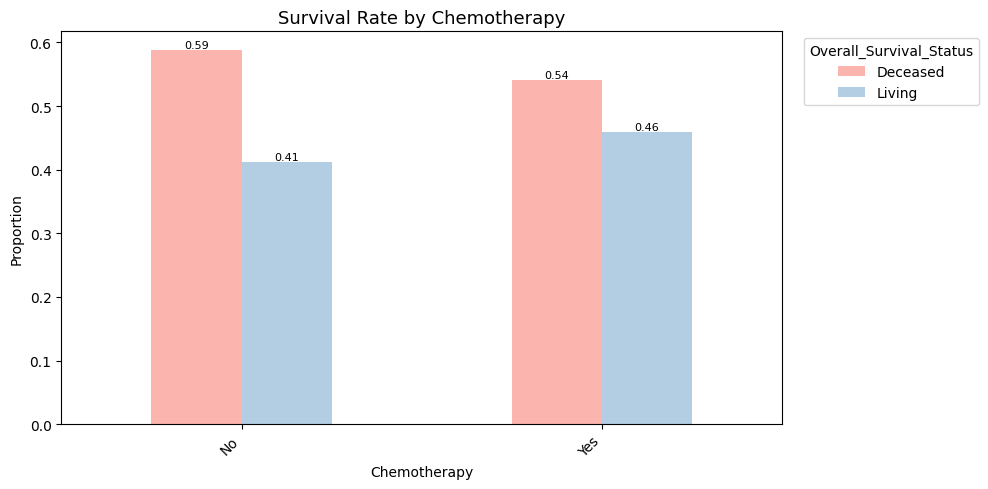

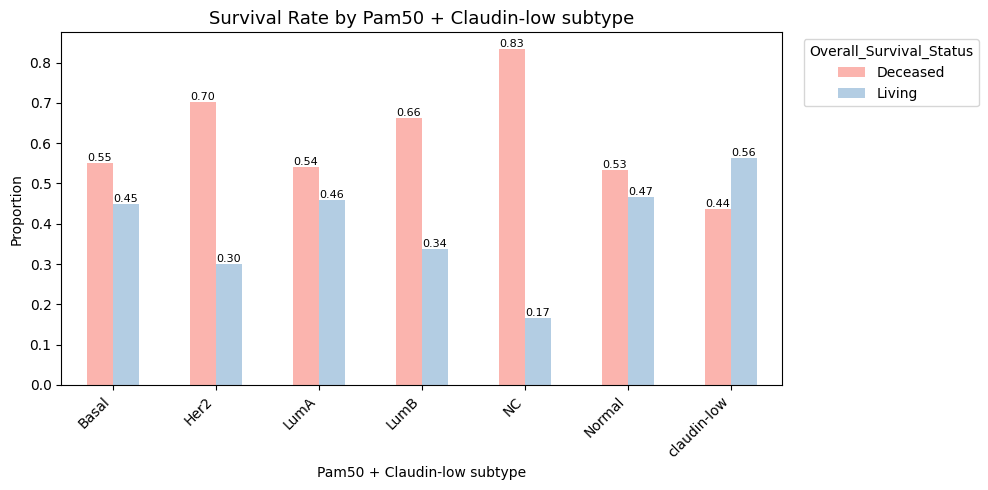

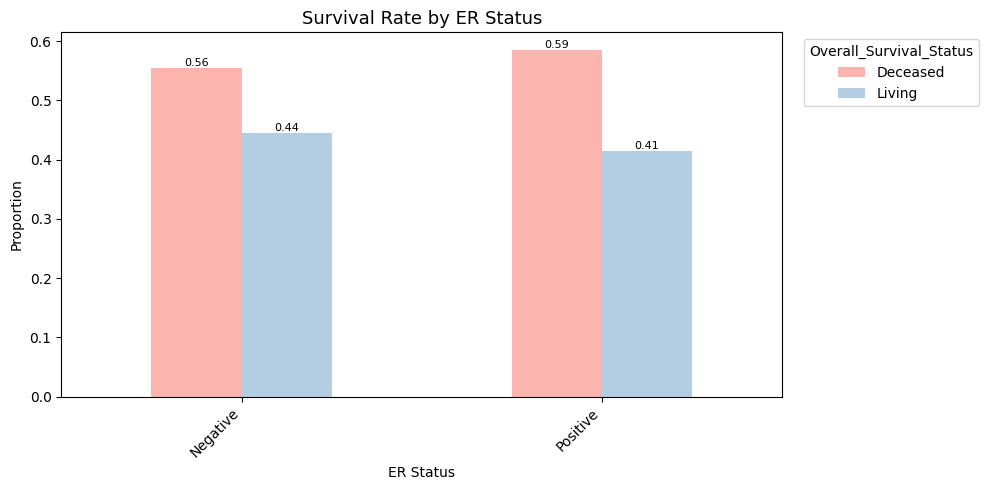

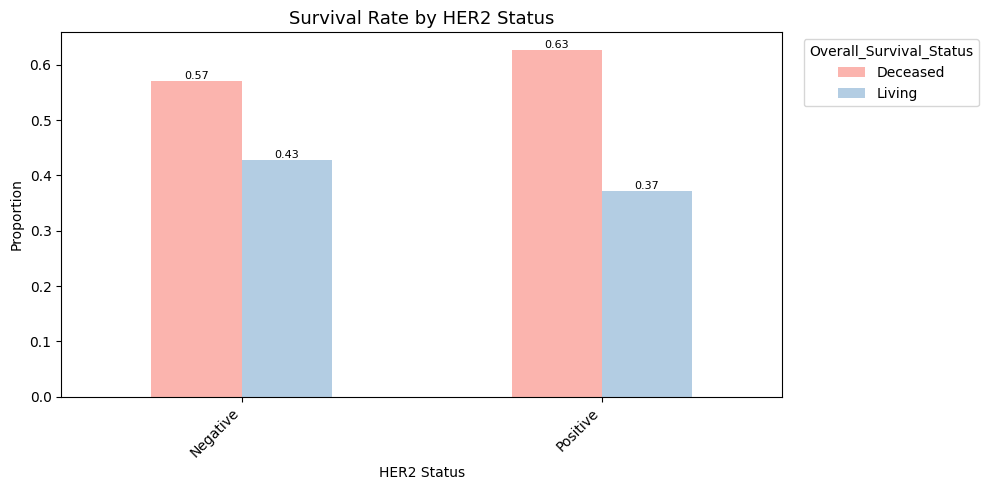

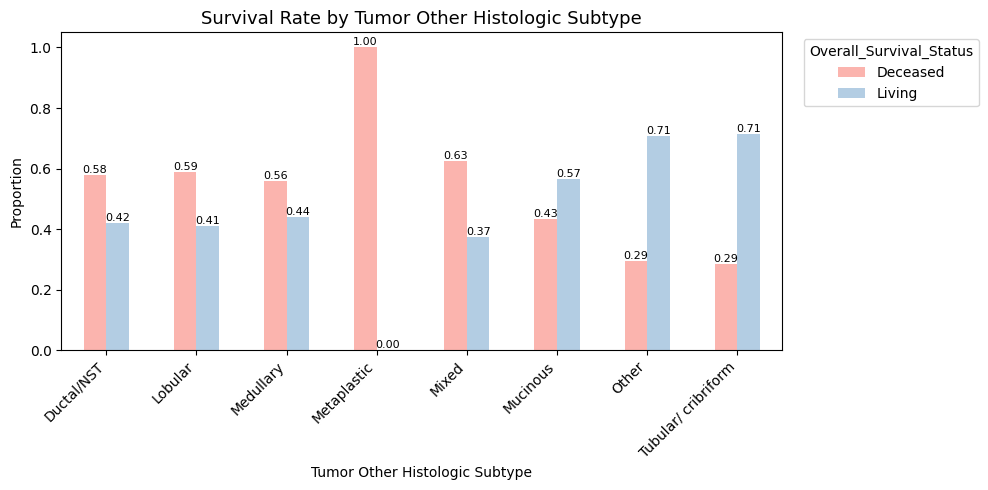

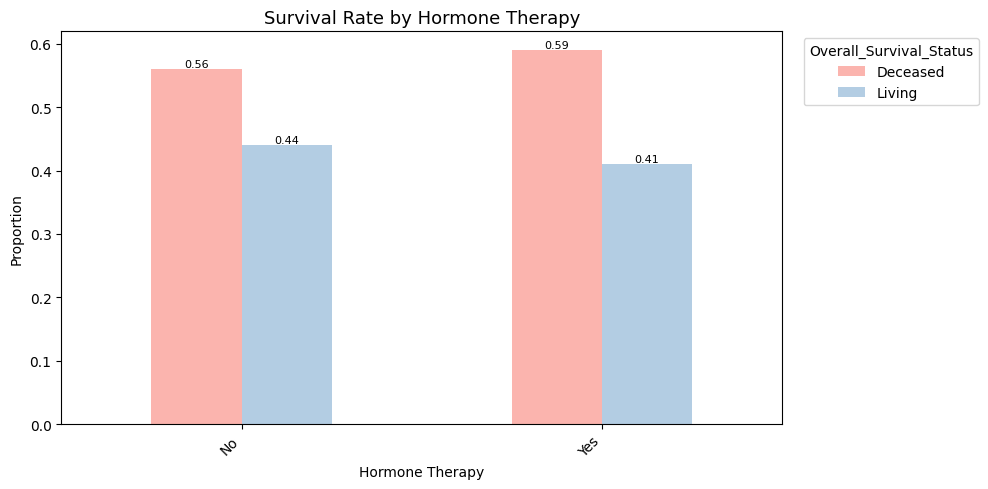

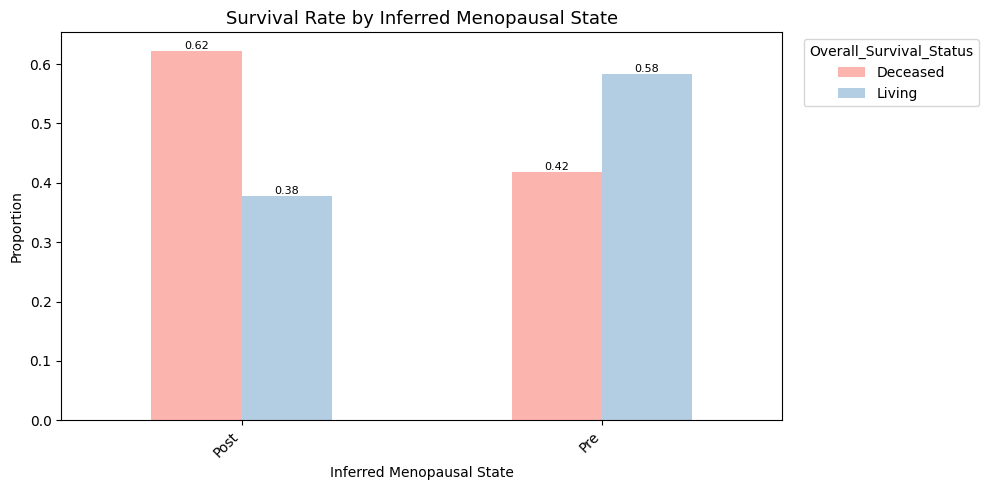

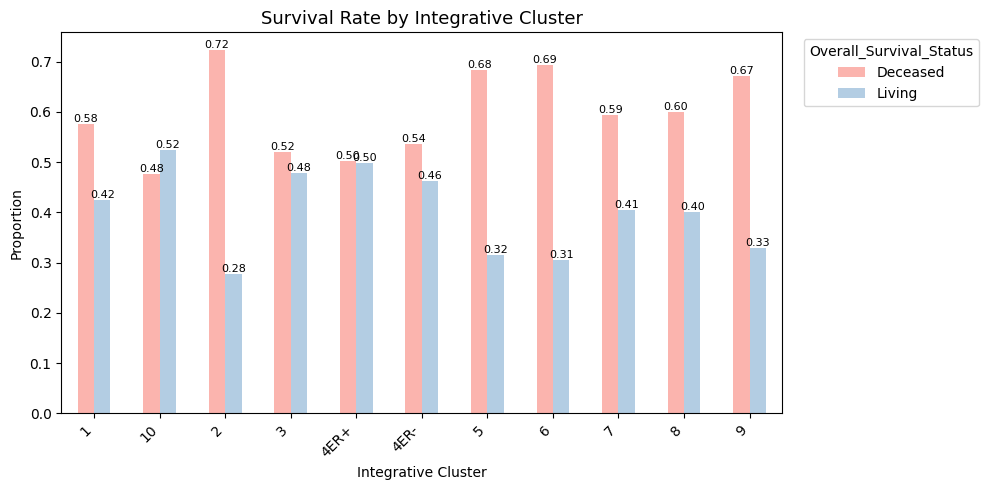

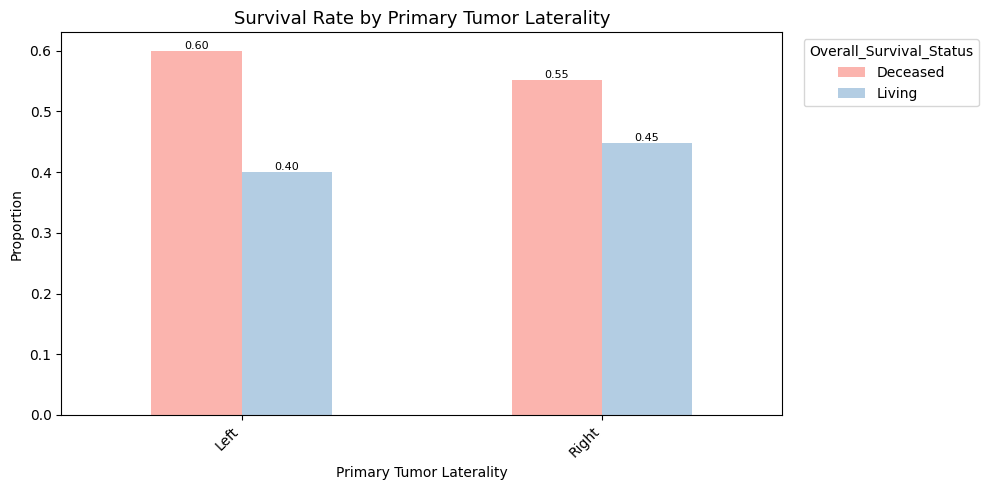

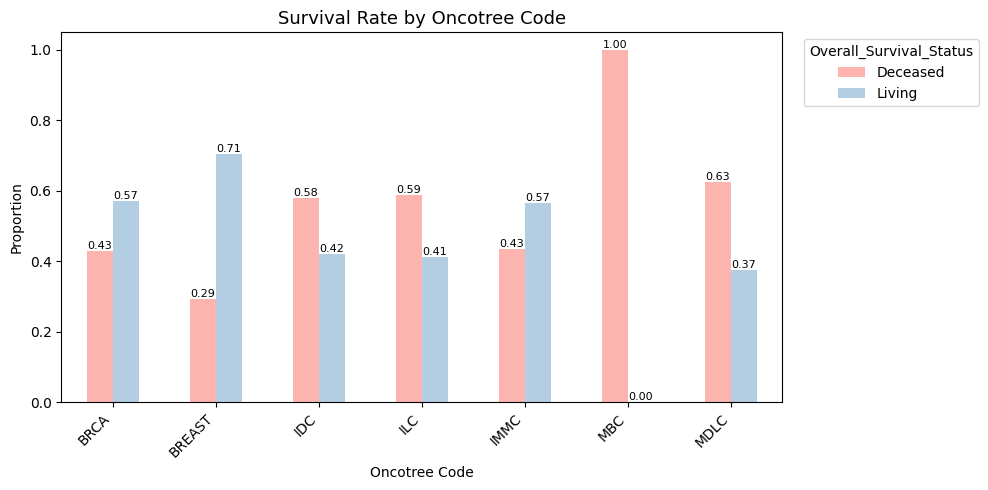

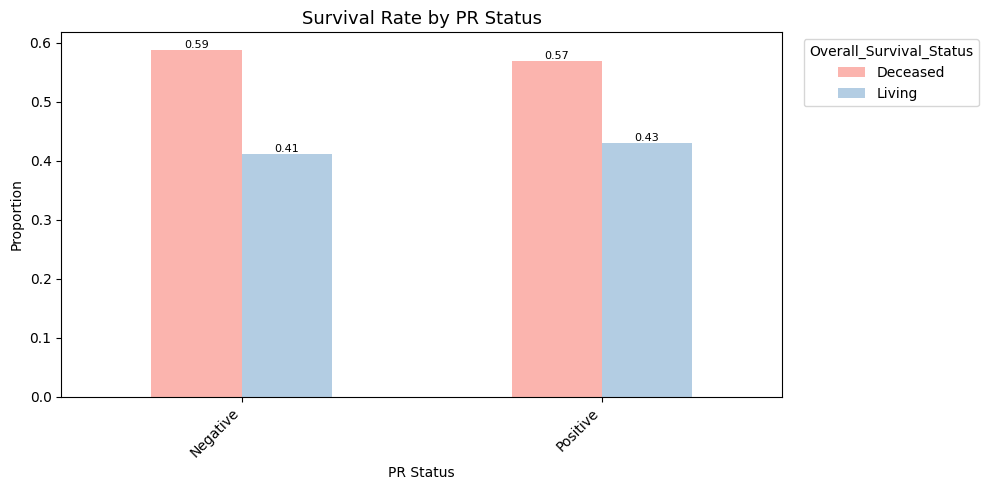

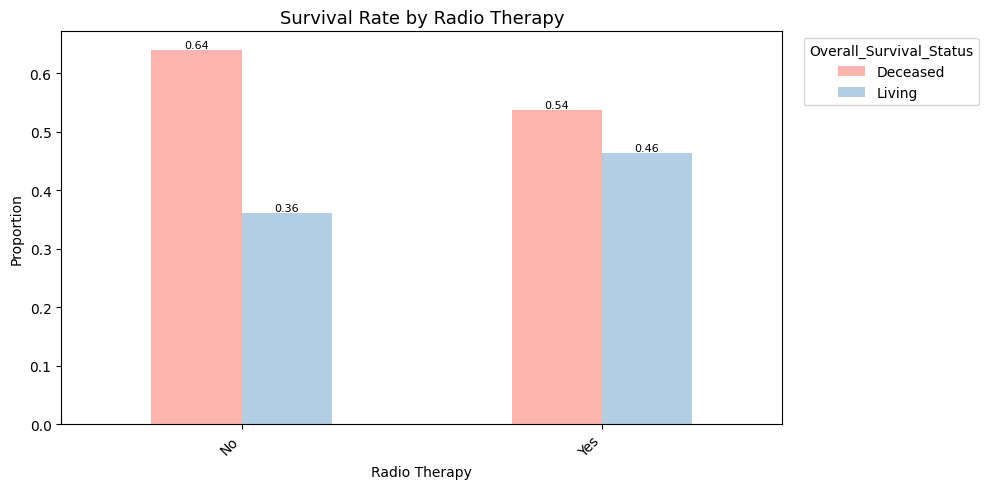

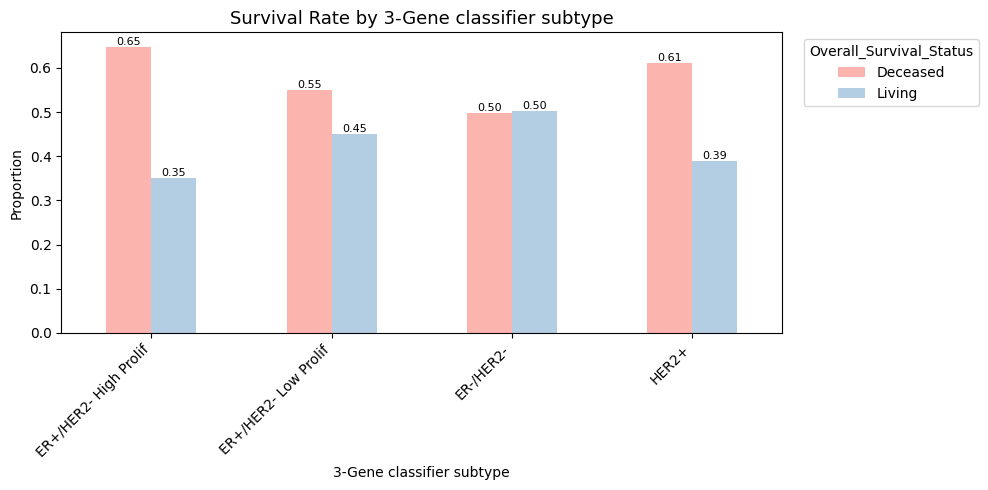

In [16]:
pastel_colors = sns.color_palette("Pastel1", n_colors=df[TARGET].nunique())

for col in categorical_cols:
    prop = pd.crosstab(df[col], df[TARGET], normalize="index")

    ax = prop.plot(kind="bar", figsize=(10, 5), color=pastel_colors)
    plt.title(f"Survival Rate by {col}", fontsize=13)
    plt.ylabel("Proportion")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title=TARGET, bbox_to_anchor=(1.02, 1), loc="upper left")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=8)

    plt.tight_layout()
    plt.show()

## 8. Numeric values by survival status
Boxplots split by target class — more directly answers "does this value differ between outcomes" than another set of overall histograms.

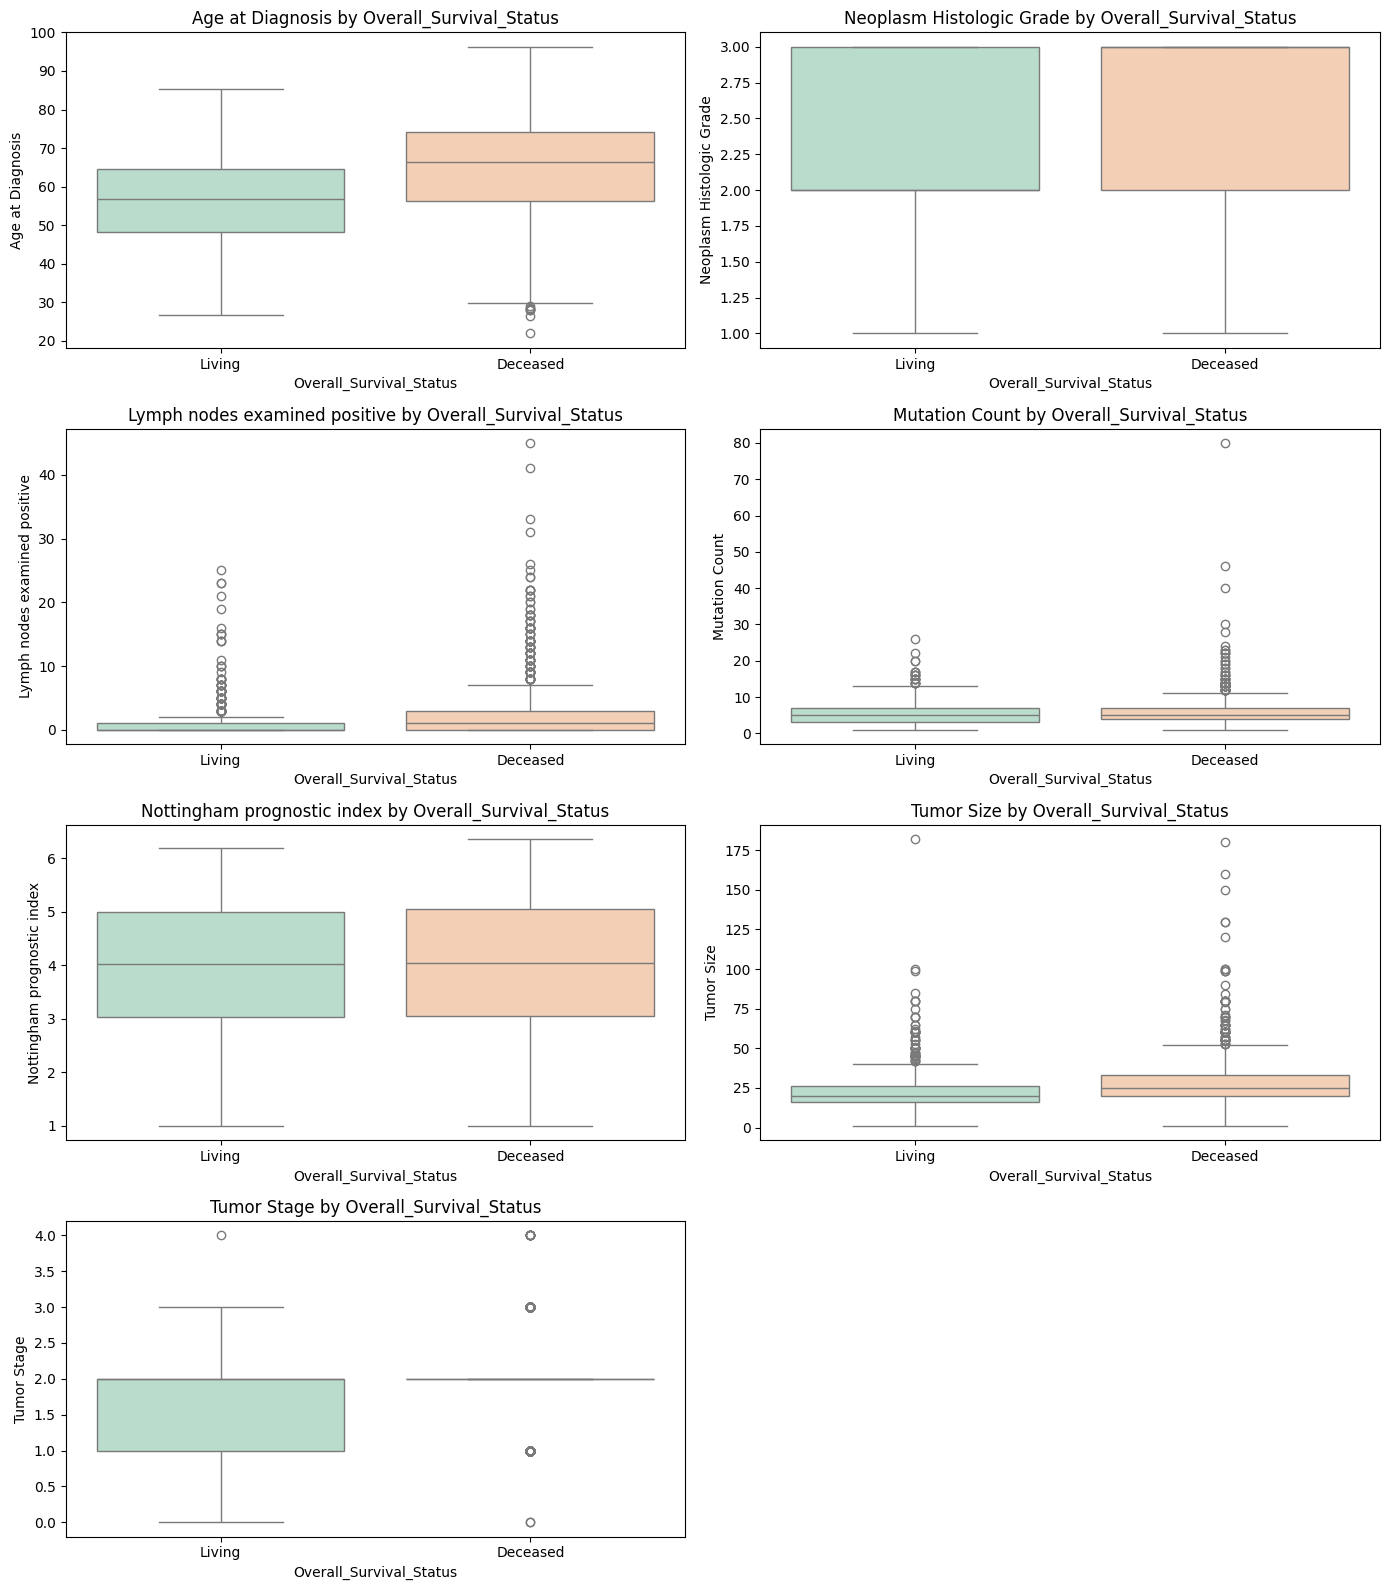

In [17]:
n_cols = 2
n_rows = -(-len(numeric_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x=TARGET, y=col, hue=TARGET, palette="Pastel2", legend=False, ax=ax)
    ax.set_title(f"{col} by {TARGET}")

for ax in axes[len(numeric_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 9. Correlation analysis
Fixing the previous bug: the target values are `Living`/`Deceased`, not `No`/`Yes`. Also restoring the feature-vs-target correlations that the earlier version dropped from the output — they're the most directly useful numbers for feature selection.

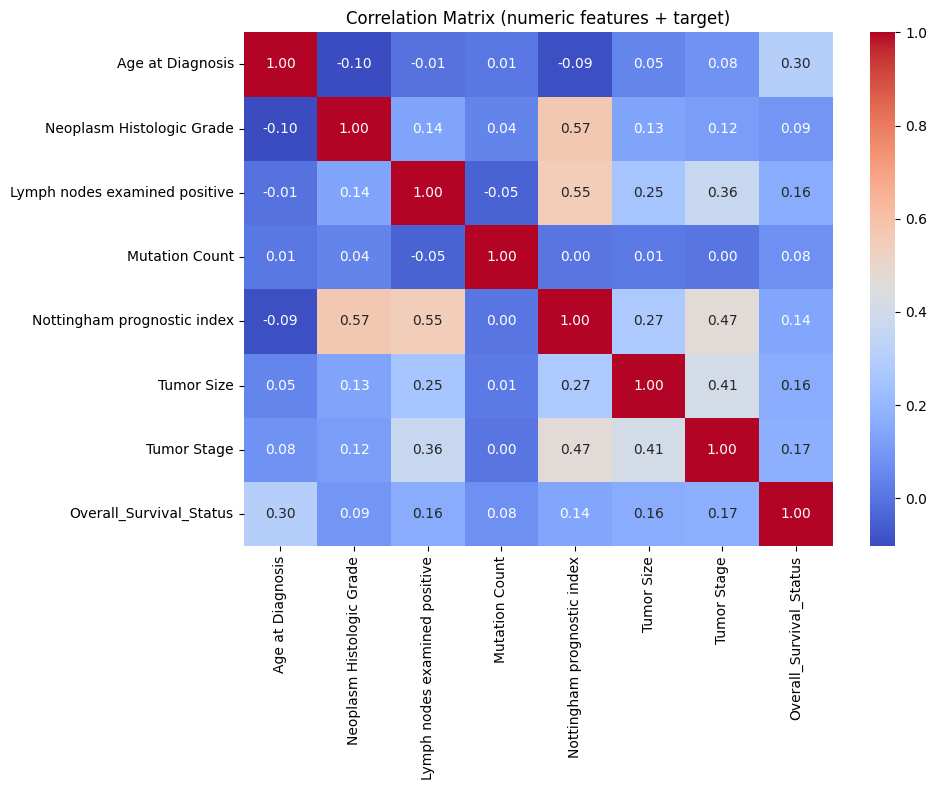

In [18]:
df_corr = df.copy()
target_map = {"Living": 0, "Deceased": 1}
df_corr[TARGET] = df_corr[TARGET].map(target_map)

corr_data = df_corr[numeric_cols + [TARGET]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_data, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (numeric features + target)")
plt.tight_layout()
plt.show()

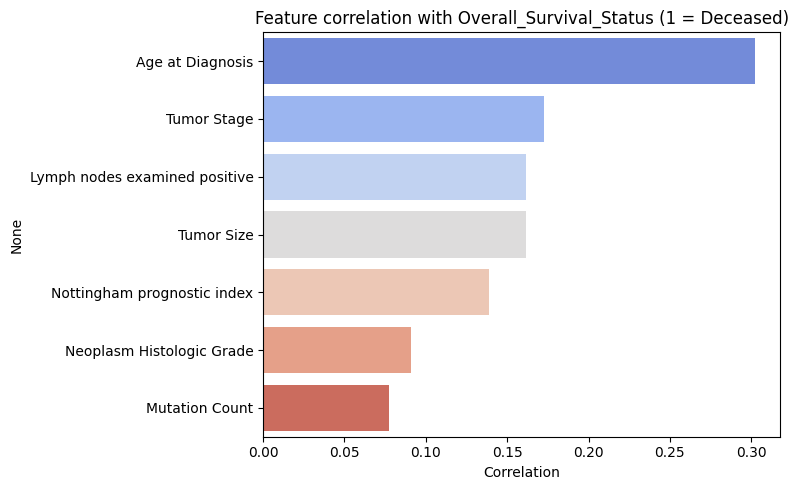

Age at Diagnosis                 0.302587
Tumor Stage                      0.172849
Lymph nodes examined positive    0.161538
Tumor Size                       0.161303
Nottingham prognostic index      0.138734
Neoplasm Histologic Grade        0.090985
Mutation Count                   0.077127
Name: Overall_Survival_Status, dtype: float64

In [19]:
target_corr = corr_data[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.index,
            palette="coolwarm", legend=False)
plt.title(f"Feature correlation with {TARGET} (1 = Deceased)")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

target_corr

`Overall Survival (Months)` and `Relapse Free Status (Months)` — the two columns flagged earlier as leakage-risk — unsurprisingly show the strongest correlation with the target. This confirms they should be excluded from the feature matrix for a classifier predicting `Overall_Survival_Status`; among the remaining features, correlations are much more modest.

## 10. Summary of findings
- Target `Overall_Survival_Status` is moderately imbalanced (~58% Living / ~42% Deceased) — plan for stratified splitting and consider class weighting.
- Several categorical fields (`3-Gene classifier subtype`, `Tumor Stage`, `Primary Tumor Laterality`, `Cellularity`) have high missingness and will need a documented imputation or missing-indicator strategy in the modeling pipeline.
- Numeric features are right-skewed (Tumor Size, Mutation Count) with some clinically plausible extreme values — favor median imputation and tree-based models (or apply a transform for linear/SVM models) over blind outlier removal.
- Next step: build the modular preprocessing pipeline (encoding, scaling, imputation fit on train only) and the model-selection/training script.